In [ ]:
# 0. Импорт библиотек

import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации


from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #разделение выборки
from sklearn import ensemble #ансамблевые методы


In [ ]:
# 1. Разведочный анализ данных (EDA)

chronic_kidney_disease = pd.read_csv('/Users/konstantingeneralov/IDE/Data/chronic.csv', sep=',')
ckd_1 = chronic_kidney_disease.copy()

# делаем максимальное кол-ва строк и столбцов, чтобы увидеть всю таблицу
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


#проверим наличие дубликатов
duplicate_rows = ckd_1.duplicated().sum()
print("Количество дубликатов в данных:", duplicate_rows)
# проверим наличие пропущенных значений и уникальных значений в каждом столбце
summary = pd.DataFrame({
    "missing": ckd_1.isnull().sum(),
    "unique": ckd_1.nunique(),
    "dtype": ckd_1.dtypes
})
display(summary)

display(ckd_1.head(), ckd_1.info(), ckd_1.describe(include='all'))

Количество дубликатов в данных: 0


,missing,unique,dtype
age,0,77,str
bp,0,11,str
sg,0,6,str
al,0,7,str
su,0,7,str
rbc,0,3,str
pc,0,3,str
pcc,0,3,str
ba,0,3,str
bgr,0,147,str


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     400 non-null    str  
 1   bp      400 non-null    str  
 2   sg      400 non-null    str  
 3   al      400 non-null    str  
 4   su      400 non-null    str  
 5   rbc     400 non-null    str  
 6   pc      400 non-null    str  
 7   pcc     400 non-null    str  
 8   ba      400 non-null    str  
 9   bgr     400 non-null    str  
 10  bu      400 non-null    str  
 11  sc      400 non-null    str  
 12  sod     400 non-null    str  
 13  pot     400 non-null    str  
 14  hemo    400 non-null    str  
 15  pcv     400 non-null    str  
 16  wc      400 non-null    str  
 17  rc      400 non-null    str  
 18  htn     400 non-null    str  
 19  dm      400 non-null    str  
 20  cad     400 non-null    str  
 21  appet   400 non-null    str  
 22  pe      400 non-null    str  
 23  ane     400 non-null    st

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,class
0,48,80,1.020,1,0,?,normal,notpresent,notpresent,121,36,1.2,?,?,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7,50,1.020,4,0,?,normal,notpresent,notpresent,?,18,0.8,?,?,11.3,38,6000,?,no,no,no,good,no,no,ckd
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,53,1.8,?,?,9.6,31,7500,?,no,yes,no,poor,no,yes,ckd
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,56,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,26,1.4,?,?,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


None

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,class
count,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400
unique,77,11,6,7,7,3,3,3,3,147,119,87,35,43,119,43,90,49,3,4,3,3,3,3,2
top,60,80,1.020,0,0,normal,normal,notpresent,notpresent,?,?,1.2,?,?,?,?,?,?,no,no,no,good,no,no,ckd
freq,19,116,106,199,290,201,259,354,374,44,19,40,87,88,52,71,106,131,251,261,364,317,323,339,250


In [ ]:
# Выводы:
# С первого взгляда видно что в данных нет пропущенных значений и дубликатов, а также что целевая переменная 'class' имеет 2 уникальных значения, что указывает на задачу классификации.
# Также можно заметить, что некоторые числовые признаки имеют большое количество уникальных значений, что может потребовать нормализации или стандартизации перед обучением модели.
# Также видно что пропущенные значения заменены на знак ?, что может потребовать дополнительной обработки для корректного анализа и моделирования данных.

In [ ]:
# 2.1 Предобработка данных

# Заменим знак ? на NaN
ckd_1.replace('?', np.nan, inplace=True)



# проверим наличие пропущенных значений и уникальных значений в каждом столбце
summary = pd.DataFrame({
    "missing": ckd_2.isnull().sum(),
    "unique": ckd_2.nunique(),
    "dtype": ckd_2.dtypes
})
display(summary)

# посмотрим все уникальные значения в каждом столбцах где немного уникальных значений
# поместим все униные значения в таблицу
unique_values = pd.DataFrame({
    "column": ckd_1.columns,
    "unique_values": [ckd_1[col].unique() for col in ckd_1.columns]
})
display(unique_values)

# в столбце dm есть 3 уникальных значения: 'yes', 'no', ' yes' (с пробелом в начале). Это может быть результатом ошибки при вводе данных. 
# удалим пробел в начале строки ' yes' и заменим его на 'yes'
ckd_1['dm'] = ckd_1['dm'].str.strip()  # удаляем пробелы в начале и конце строк в столбце 'dm'
# проверим уникальные значения в столбце dm после удаления пробелов
print(ckd_1['dm'].unique())

ckd_2=ckd_1.copy()

# поменяем категориальные признаки на числовые в столбцах где есть 2 уникальных значения yes no 
binary_cols = ['htn', 'dm', 'cad', 'pe', 'ane']
for col in binary_cols:
    ckd_2[col] = ckd_2[col].map({'yes': 1, 'no': 0})
# сделаем их Int64, так как после замены они стали float и могут содержать NA
ckd_2[binary_cols] = ckd_2[binary_cols].astype('Int64')    

# заменим категориальные признаки в столбце 'class' на числовые
ckd_2['class'] = ckd_2['class'].map({'ckd': 1, 'notckd': 0})
# заменим квтегориальные в pcc ba на числовые
ckd_2['ba'] = ckd_2['ba'].map({'present': 1, 'notpresent': 0}).astype('Int64')
ckd_2['pcc'] = ckd_2['pcc'].map({'present': 1, 'notpresent': 0}).astype('Int64')

# заменим категориальные признаки в столбцах rbc и pc на числовые
ckd_2['rbc'] = ckd_2['rbc'].map({'normal': 0, 'abnormal': 1}).astype('Int64')
ckd_2['pc'] = ckd_2['pc'].map({'normal': 0, 'abnormal': 1}).astype('Int64')

# заменим категориальные признаки в столбце 'appet' на числовые
ckd_2['appet'] = ckd_2['appet'].map({'good': 0, 'poor': 1}).astype('Int64')

# создадим uncoding dict для всего датасета
uncoding_dict = {
    'htn': {1: 'yes', 0: 'no'},
    'dm': {1: 'yes', 0: 'no'},
    'cad': {1: 'yes', 0: 'no'},
    'pe': {1: 'yes', 0: 'no'},
    'ane': {1: 'yes', 0: 'no'},
    'class': {1: 'ckd', 0: 'notckd'},
    'ba': {1: 'present', 0: 'notpresent'},
    'pcc': {1: 'present', 0: 'notpresent'},
    'rbc': {0: 'normal', 1: 'abnormal'},
    'pc': {0: 'normal', 1: 'abnormal'},
    'appet': {0: 'good', 1: 'poor'}
}
print(uncoding_dict)
display(ckd_2.head(), ckd_2.info(), ckd_2.describe(include='all'))

,missing,unique,dtype
age,9,76,str
bp,12,10,str
sg,47,5,str
al,46,6,str
su,49,6,str
rbc,152,2,Int64
pc,65,2,Int64
pcc,4,2,Int64
ba,4,2,Int64
bgr,44,146,str


,column,unique_values
0,age,"[48, 7, 62, 51, 60, 68, 24, 52, 53, 50, 63, 40, 47, 61, 21, 42, 75, 69, nan, 73, 70, 65, 76, 72, 82, 46, 45, 35, 54, 11, 59, 67, 15, 55, 44, 26, 64, 56, 5, 74, 38, 58, 71, 34, 17, 12, 43, 41, 57, 8, 39, 66, 81, 14, 27, 83, 30, 4, 3, 6, 32, 80, 49, 90, 78, 19, 2, 33, 36, 37, 23, 25, 20, 29, 28, 22, 79]"
1,bp,"[80, 50, 70, 90, nan, 100, 60, 110, 140, 180, 120]"
2,sg,"[1.020, 1.010, 1.005, 1.015, nan, 1.025]"
3,al,"[1, 4, 2, 3, 0, nan, 5]"
4,su,"[0, 3, 4, 1, nan, 2, 5]"
5,rbc,"[nan, normal, abnormal]"
6,pc,"[normal, abnormal, nan]"
7,pcc,"[notpresent, present, nan]"
8,ba,"[notpresent, present, nan]"
9,bgr,"[121, nan, 423, 117, 106, 74, 100, 410, 138, 70, 490, 380, 208, 98, 157, 76, 99, 114, 263, 173, 95, 108, 156, 264, 123, 93, 107, 159, 140, 171, 270, 92, 137, 204, 79, 207, 124, 144, 91, 162, 246, 253, 141, 182, 86, 150, 146, 425, 112, 250, 360, 163, 129, 133, 102, 158, 165, 132, 104, 127, 415, 169, 251, 109, 280, 210, 219, 295, 94, 172, 101, 298, 153, 88, 226, 143, 115, 89, 297, 233, 294, 323, 125, 90, 308, 118, 224, 128, 122, 214, 213, 268, 256, 84, 105, 288, 139, 78, 273, 242, ...]"


<StringArray>
['yes', 'no', nan]
Length: 3, dtype: str
{'htn': {1: 'yes', 0: 'no'}, 'dm': {1: 'yes', 0: 'no'}, 'cad': {1: 'yes', 0: 'no'}, 'pe': {1: 'yes', 0: 'no'}, 'ane': {1: 'yes', 0: 'no'}, 'class': {1: 'ckd', 0: 'notckd'}, 'ba': {1: 'present', 0: 'notpresent'}, 'pcc': {1: 'present', 0: 'notpresent'}, 'rbc': {0: 'normal', 1: 'abnormal'}, 'pc': {0: 'normal', 1: 'abnormal'}, 'appet': {0: 'good', 1: 'poor'}}
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     391 non-null    str  
 1   bp      388 non-null    str  
 2   sg      353 non-null    str  
 3   al      354 non-null    str  
 4   su      351 non-null    str  
 5   rbc     248 non-null    Int64
 6   pc      335 non-null    Int64
 7   pcc     396 non-null    Int64
 8   ba      396 non-null    Int64
 9   bgr     356 non-null    str  
 10  bu      381 non-null    str  
 11  sc      383 non-null    str  
 12

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,class
0,48,80,1.020,1,0,<NA>,0,0,0,121,36,1.2,NaN,NaN,15.4,44,7800,5.2,1,1,0,0,0,0,1
1,7,50,1.020,4,0,<NA>,0,0,0,NaN,18,0.8,NaN,NaN,11.3,38,6000,NaN,0,0,0,0,0,0,1
2,62,80,1.010,2,3,0,0,0,0,423,53,1.8,NaN,NaN,9.6,31,7500,NaN,0,1,0,1,0,1,1
3,48,70,1.005,4,0,0,1,1,0,117,56,3.8,111,2.5,11.2,32,6700,3.9,1,0,0,1,1,1,1
4,51,80,1.010,2,0,0,0,0,0,106,26,1.4,NaN,NaN,11.6,35,7300,4.6,0,0,0,0,0,0,1


None

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,class
count,391,388,353,354,351,248.0,335.0,396.0,396.0,356,381,383,313,312,348,329,294,269,398.0,398.0,398.0,399.0,399.0,399.0,400.000000
unique,76,10,5,6,6,<NA>,<NA>,<NA>,<NA>,146,118,86,34,42,118,42,89,48,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
top,60,80,1.020,0,0,<NA>,<NA>,<NA>,<NA>,99,46,1.2,135,3.5,15.0,52,9800,5.2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
freq,19,116,106,199,290,<NA>,<NA>,<NA>,<NA>,10,15,40,40,30,12,21,11,18,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.189516,0.226866,0.106061,0.055556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.369347,0.344221,0.085427,0.205514,0.190476,0.150376,0.625000
std,NaN,NaN,NaN,NaN,NaN,0.392711,0.419431,0.308305,0.229351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.483235,0.475712,0.279868,0.404584,0.39317,0.357888,0.484729
min,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
25%,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
50%,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
75%,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,0.0,1.000000


,missing,unique,dtype
age,9,76,float64
bp,12,10,float64
sg,47,5,float64
al,46,6,float64
su,49,6,float64
rbc,152,2,Int64
pc,65,2,Int64
pcc,4,2,Int64
ba,4,2,Int64
bgr,44,146,float64


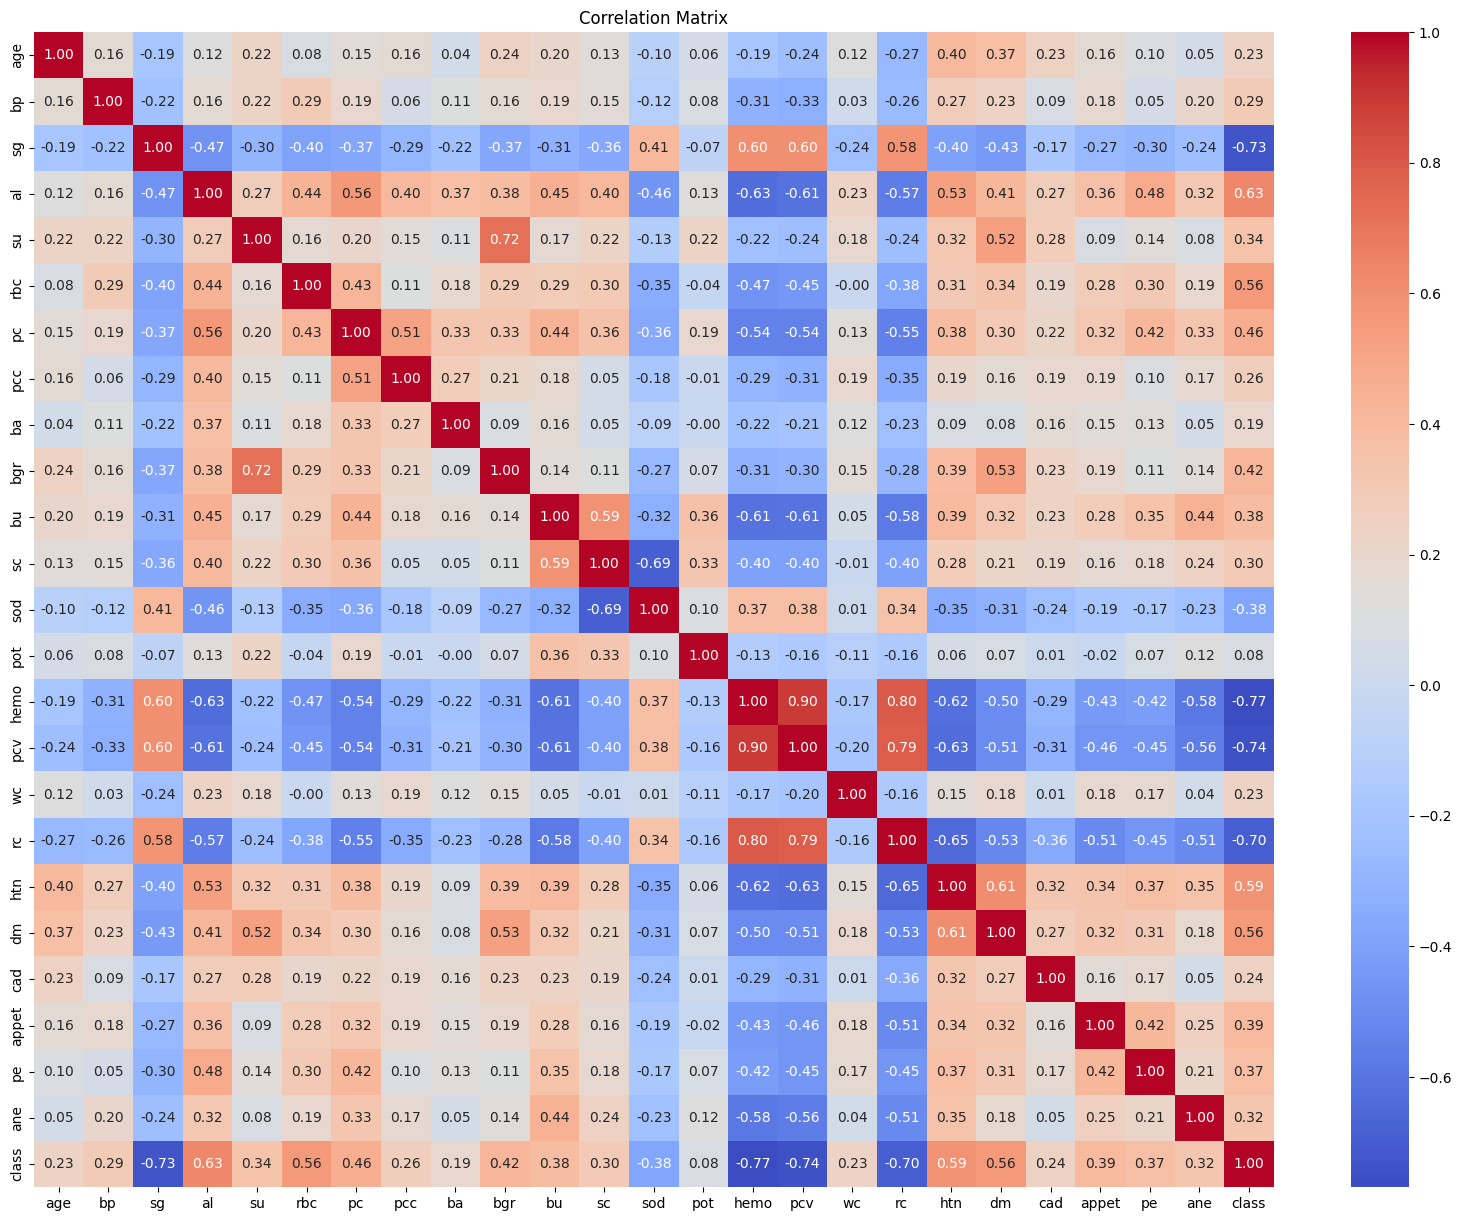

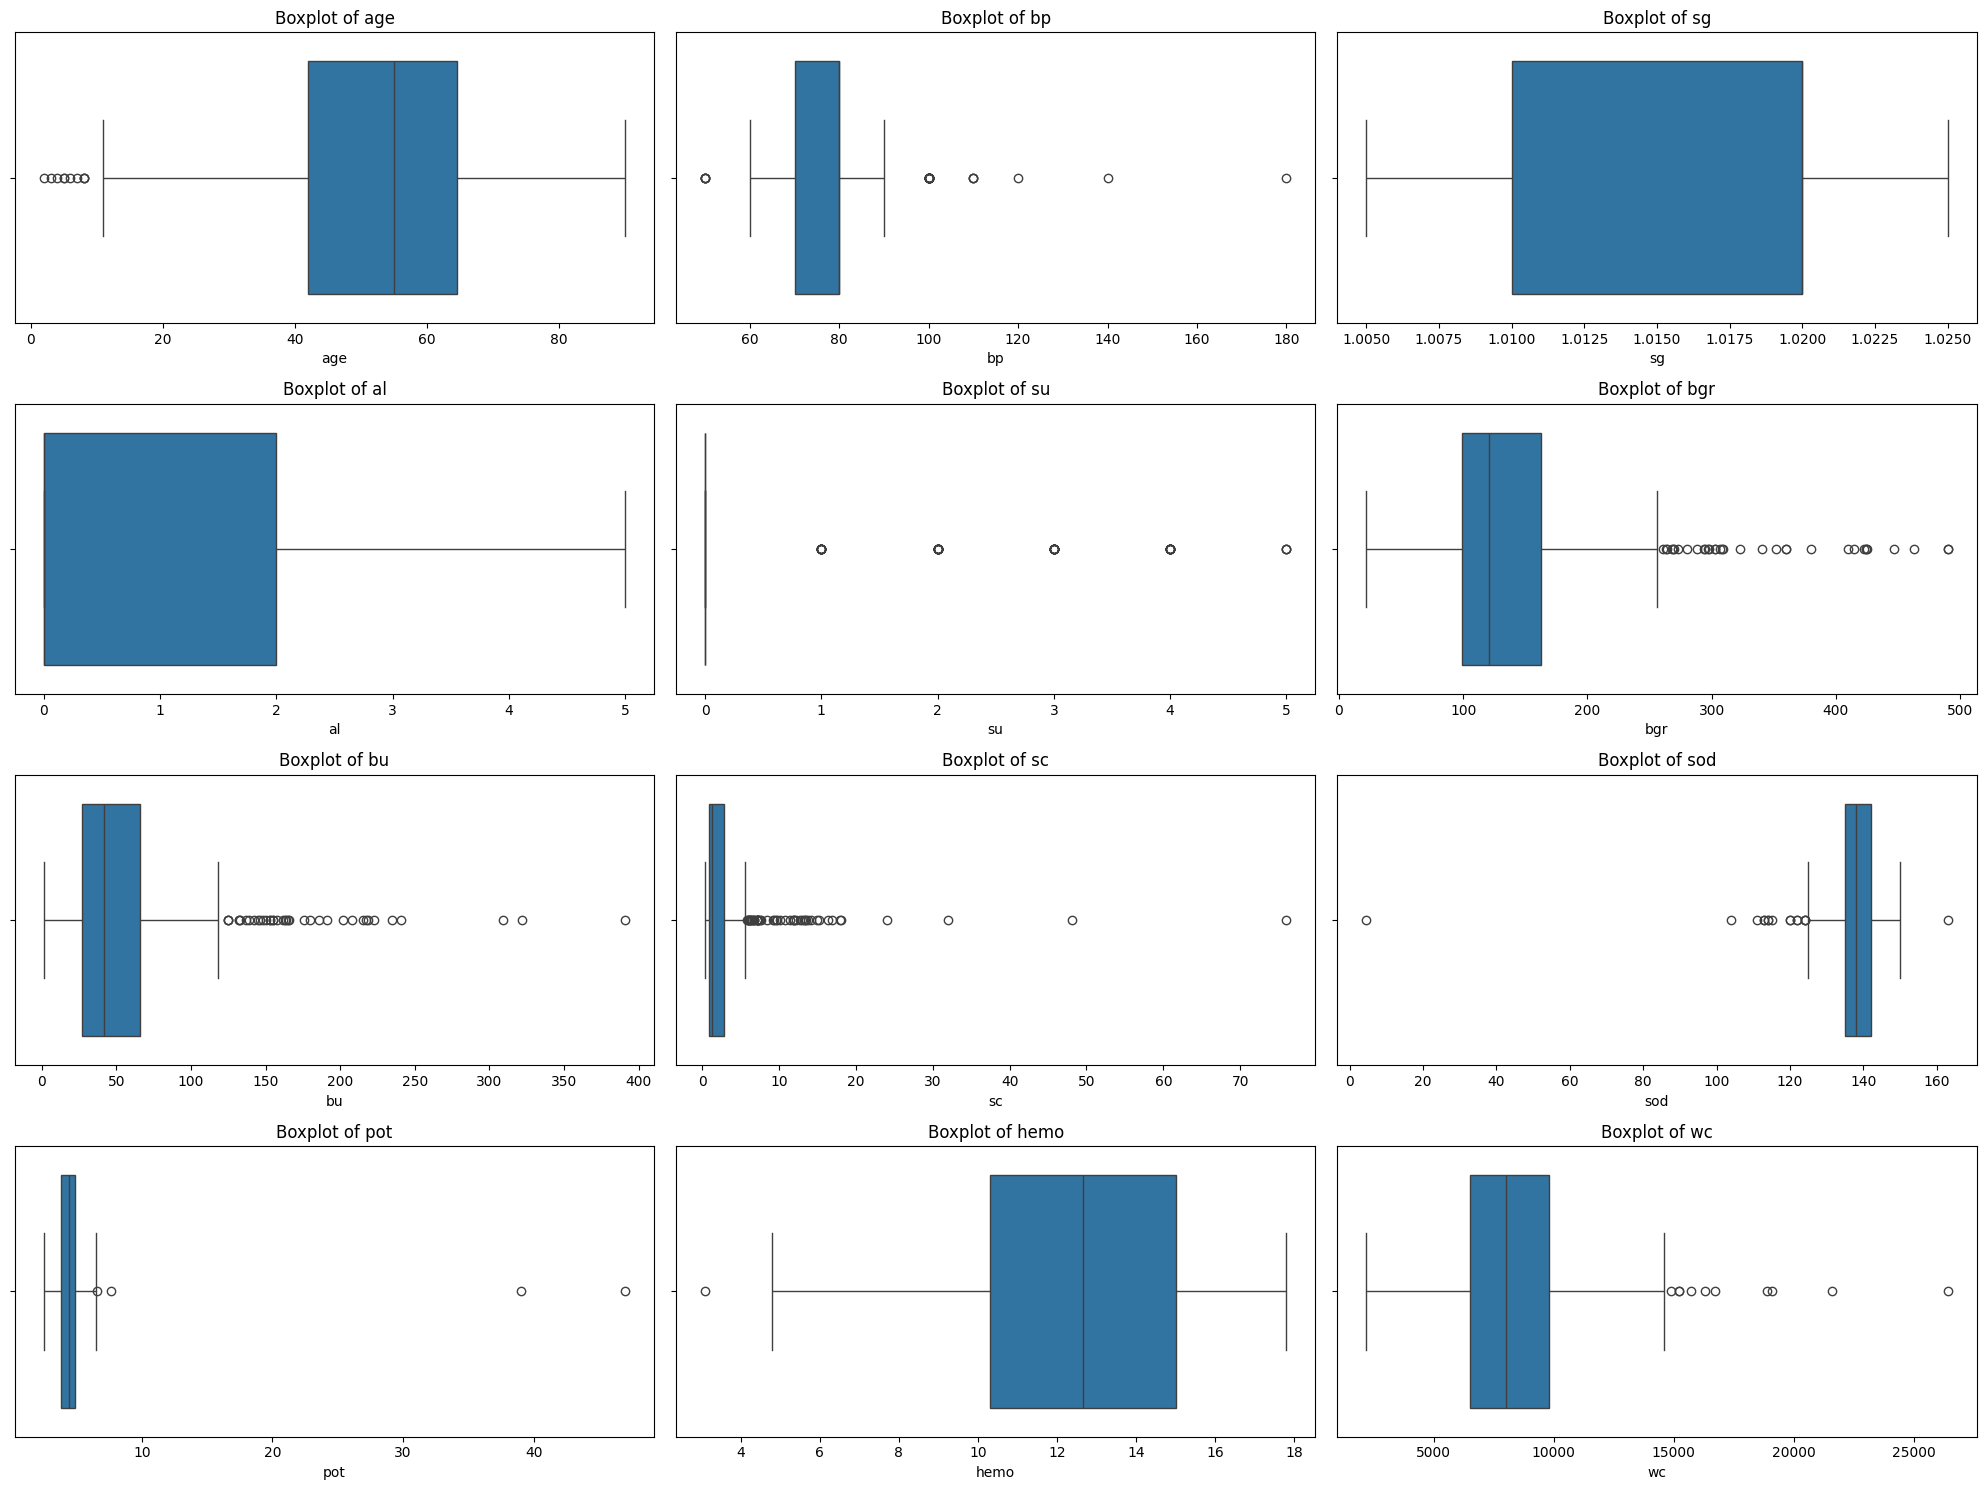

In [ ]:
# 2.2 Предобработка данных

ckd_3 = ckd_2.copy()
# сделаем все числовые значения числовыми, так как сейчас они в виде строк кроме rbc, pc, appet

num_cols_to_float = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
for col in num_cols_to_float:
    ckd_3[col] = pd.to_numeric(ckd_3[col], errors='coerce')

summary = pd.DataFrame({
    "missing": ckd_3.isnull().sum(),
    "unique": ckd_3.nunique(),
    "dtype": ckd_3.dtypes
})
display(summary)

# выгрузим новый файл с предобработанными данными
ckd_3.to_csv('/Users/konstantingeneralov/IDE/Data/chronic_kidney_disease_preprocessed.csv', index=False)

ckd_4=ckd_3.copy()
# удалим дублируещие признаки, так как они не несут полезной информации для модели
ckd_4.drop(columns=['pcv', 'rc'], inplace=True)

# построим кореляционную матрицу для числовых признаков пошире чтобы было видно все признаки
plt.figure(figsize=(20, 15))
sns.heatmap(ckd_3.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# проверим выбросы в числовых признаках с помощью boxplotов
num_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'wc']
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i+1)
    sns.boxplot(x=ckd_4[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [ ]:
# Выводы: 
# 1. Датафрейм представляет собой таблицу с различными медицинскими признаками и целевой переменной 'class', 
# которая указывает на наличие или отсутствие хронической болезни почек (ckd).
# 2. Было выявлено, что пропущенные значения в данных представлены в виде знака '?', который был заменен на NaN для корректной обработки.
# 3. Категориальные признаки были успешно преобразованы в числовые, что является важным шагом для подготовки данных к моделированию.
# 4. Корреляционная матрица показала, что некоторые числовые признаки имеют высокую корреляцию между собой. Например al=0.63, rbc=0.56, htn=0.59, dm=0.56, sg=-0,73, hemo=-0.77,
# pcv=-0.74, rc=-0.70
# Анализ корреляций показал, что снижение плотности мочи, уровня гемоглобина, гематокрита и количества эритроцитов статистически связано с наличием хронической болезни почек,
# что отражает потерю концентрационной функции почек и развитие анемии. Повышение уровня альбумина в моче, 
# а также наличие гипертензии и сахарного диабета положительно коррелируют с ХБП, подтверждая их роль как ключевых факторов риска.
# 5. Что бы убрать мультиколлинеарность, можно удалить признаки pcv, rc оставить один hemo, так как он имеет самую высокую корреляцию с целевой переменной class 
# и является клинически значимым показателем анемии при ХБП. 
# 6. Анализ выбросов показал что имеются не физиологичные значения в признаках bgr, bu, sc, sod, pot. 

,missing,unique,dtype
age,0,76,float64
bp,0,10,float64
sg,0,5,float64
al,0,6,float64
su,0,6,float64
rbc,0,2,Int64
pc,0,2,Int64
pcc,0,2,Int64
ba,0,2,Int64
bgr,0,146,float64


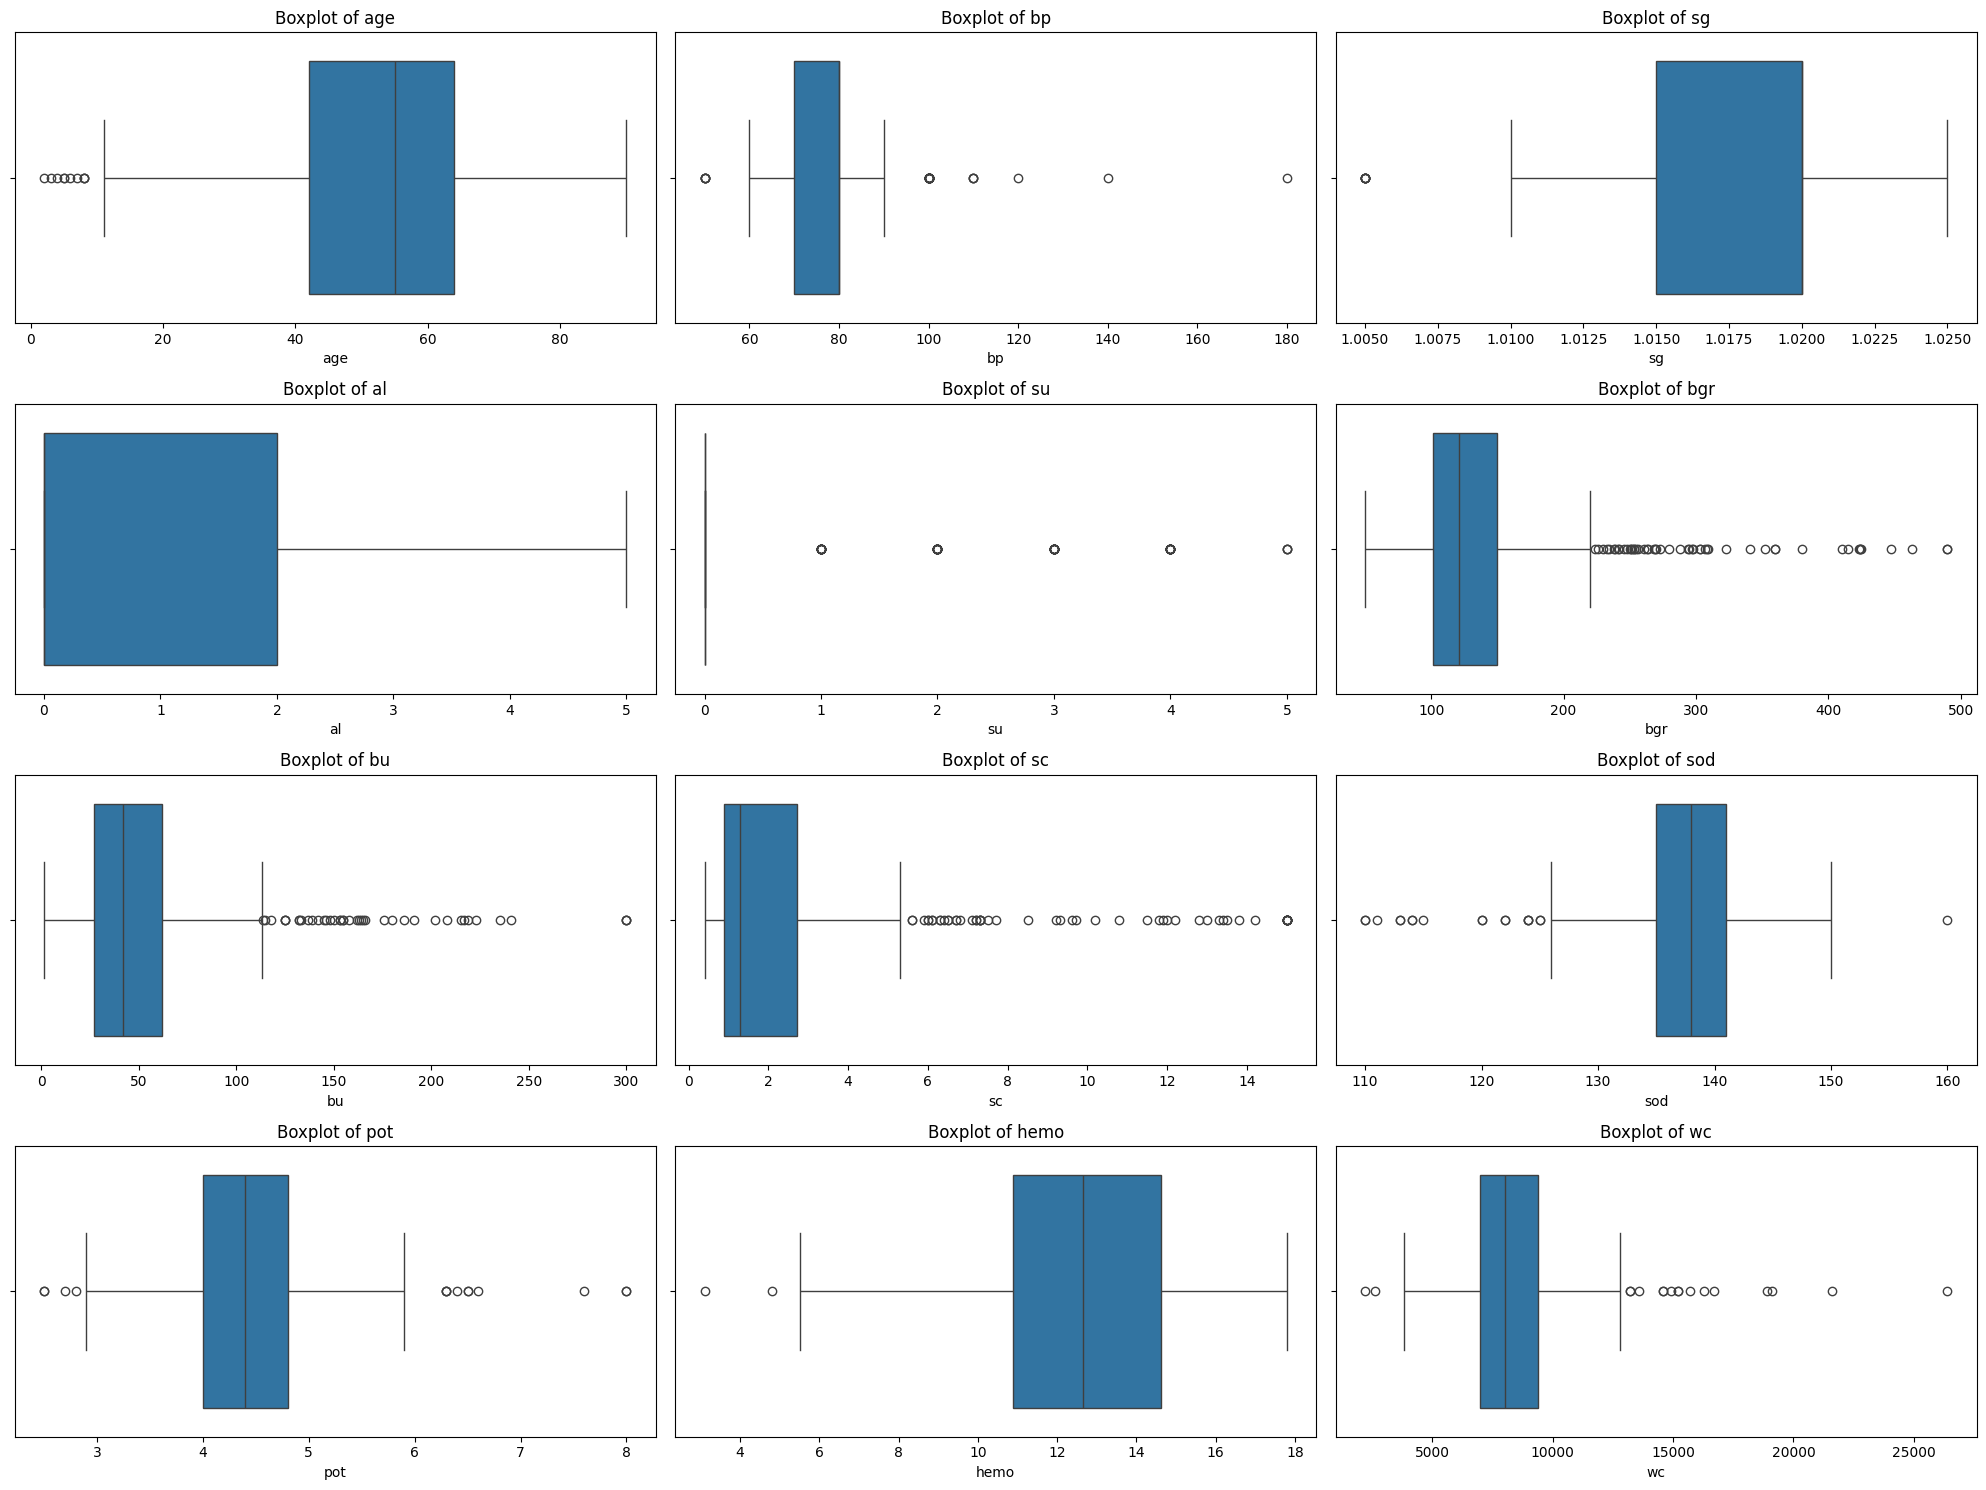

Ранг матрицы корреляций: 23
Определитель матрицы корреляций: 0.00011525581736908385


In [105]:
# 2.3 Предобработка данных. 
# Заполним пропуски и удалим выбросы

# заполним пропуски в столбцах rbc и pc модой, так как эти признаки категориальные и имеют небольшое количество уникальных значений.
# Мы предполагаем: Если значение не записали, скорее всего оно было типичным. Намного лучше заполнить пропуски типичным значением, чем удалять строки с пропусками, 
# так как это может привести к потере важной информации и уменьшению размера обучающей выборки.
cat_cols = ['rbc', 'pc', 'htn','dm','cad','appet','pe','ane','pcc','ba']
for col in cat_cols:
    ckd_4[col] = ckd_4[col].fillna(ckd_4[col].mode()[0])
    
# заполним пропуски в числовых столбцах медианой, так как эти признаки числовые и могут содержать выбросы.
num_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'wc']
ckd_4[num_cols] = ckd_4[num_cols].fillna(ckd_4[num_cols].median())

summary = pd.DataFrame({
    "missing": ckd_4.isnull().sum(),
    "unique": ckd_4.nunique(),
    "dtype": ckd_4.dtypes
})
display(summary)

ckd_5 = ckd_4.copy()

# удалим выбросы в числовых признаках "Clinical thresholds"
ckd_5['sc'] = ckd_5['sc'].clip(0, 15)
ckd_5['pot'] = ckd_5['pot'].clip(2, 8)
ckd_5['sod'] = ckd_5['sod'].clip(110, 160)
ckd_5['bu'] = ckd_5['bu'].clip(0, 300)
ckd_5['bgr'] = ckd_5['bgr'].clip(50, 600)

# проверим выбросы в числовых признаках с помощью boxplotов
num_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'wc']
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i+1)
    sns.boxplot(x=ckd_5[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

corr_matrix = ckd_5.corr()
rank = np.linalg.matrix_rank(corr_matrix)
det = np.linalg.det(corr_matrix)
print("Ранг матрицы корреляций:", rank)
print("Определитель матрицы корреляций:", det)

In [ ]:
# Выводы:
# провели обработку пропущенных значений, заполнив их модой для категориальных признаков и медианой для числовых признаков. 
# Это позволило сохранить важную информацию в данных и избежать потери строк с пропусками.
# Удалили выбросы в числовых признаках, что также улучшило качество данных. Привели все к физиологичным значениям, что важно для корректного анализа и моделирования данных.
# Не смотря на наличие экстремальных значений (выбросов) по ряду клинических показателей, таких как креатинин сыворотки, мочевина крови, уровень глюкозы и артериальное давление. 
# Эти значения были сохранены, так как они соответствуют тяжелым патологическим состояниям, характерным для пациентов 
# с ХБП (хронической болезнью почек), и скорее всего не являются ошибками в данных.


In [91]:
# 3. Построение моделей машинного обучения

# Подготовка данных для моделей. Разделим данные на признаки X и целевую переменную y.

X = ckd_5.drop(columns=['class'])
y = ckd_5['class']

# Разделение train / test.  stratify=y Чтобы сохранить долю CKD / notCKD.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Выберем 3 модели для классификации: Logistic Regression, Random Forest и Gradient Boosting. Обучение с кросс-валидацией. Модель обучается 5 раз на разных подвыборках.
# Это защищает от случайного результата.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
# первую будем делать логистическую регрессию
# так как данные разные нужно стандартизировать числовые признаки для логистической регрессии, так как она чувствительна к масштабу данных.
from sklearn.preprocessing import StandardScaler

num_cols = X.select_dtypes(include=['float64']).columns
cat_cols = X.select_dtypes(include=['Int64']).columns

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# обучим логистическую регрессию 

logreg = LogisticRegression(
    max_iter=5000,
    solver='lbfgs'
)

logreg.fit(X_train_scaled, y_train)

# предскажем на тестовой выборке и оценим качество модели с помощью метрик accuracy, precision, recall, f1-score и confusion matrix.

y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))
# посмотрим топ 10 самых важных признаков для логистической регрессии по абсолютному значению коэффициентов
coef = pd.Series(logreg.coef_[0], index=X.columns)
coef_sorted = coef.sort_values(key=abs, ascending=False)

coef_sorted.head(10)


Accuracy: 0.9875
Recall: 0.98
F1: 0.98989898989899
ROC-AUC: 1.0
Confusion Matrix:
 [[30  0]
 [ 1 49]]
Precision: 1.0


hemo    -2.465478
sg      -1.795686
al       1.286142
htn      1.248228
dm       1.228097
sc       1.169069
appet    1.115381
bgr      0.902104
bp       0.607598
sod     -0.555800
dtype: float64

In [102]:
from sklearn.model_selection import cross_val_score

logreg = LogisticRegression(max_iter=5000)

cv_auc = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring='roc_auc')
cv_f1  = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring='f1')

print("CV ROC-AUC:", cv_auc.mean())
print("CV F1:", cv_f1.mean())

CV ROC-AUC: 0.9997916666666666
CV F1: 0.9898710134997055


Accuracy: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0
[[30  0]
 [ 0 50]]
hemo     0.263706
sc       0.169469
sg       0.163308
htn      0.076683
al       0.073373
dm       0.053668
bu       0.047172
bgr      0.038537
bp       0.022309
sod      0.020982
appet    0.013058
age      0.010401
pc       0.009928
pe       0.009067
wc       0.007297
dtype: float64


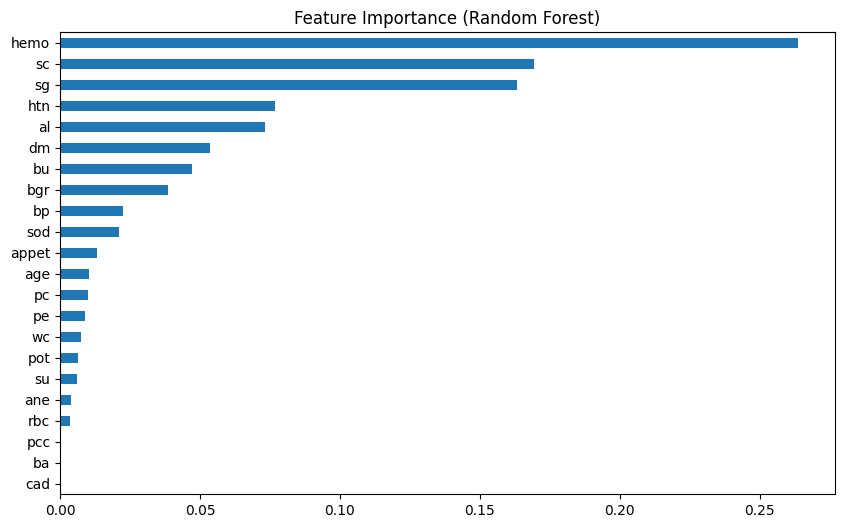

In [94]:
# random forest

rf = RandomForestClassifier(
    n_estimators=300,      # количество деревьев
    max_depth=None,        # глубина (None = до чистоты)
    random_state=42,
    class_weight='balanced' # важно для медицины
)

rf.fit(X_train, y_train)

# Предсказания
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print(confusion_matrix(y_test, y_pred_rf))

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)
print(importances.sort_values(ascending=False).head(15))
importances.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.show()

In [103]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print("CV ROC-AUC:", cv_scores.mean())

rf.fit(X_train, y_train)

train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:,1])
test_auc  = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

CV ROC-AUC: 1.0
Train AUC: 1.0
Test AUC: 1.0


Test Accuracy: 0.9875
Test Recall: 0.98
Test F1: 0.98989898989899
Test ROC-AUC: 1.0
[[30  0]
 [ 1 49]]
hemo     0.722485
sg       0.193263
al       0.021736
htn      0.018435
sod      0.013458
bu       0.012346
sc       0.012293
age      0.001680
cad      0.000990
bp       0.000898
wc       0.000887
bgr      0.000736
pe       0.000435
appet    0.000324
rbc      0.000030
dtype: float64


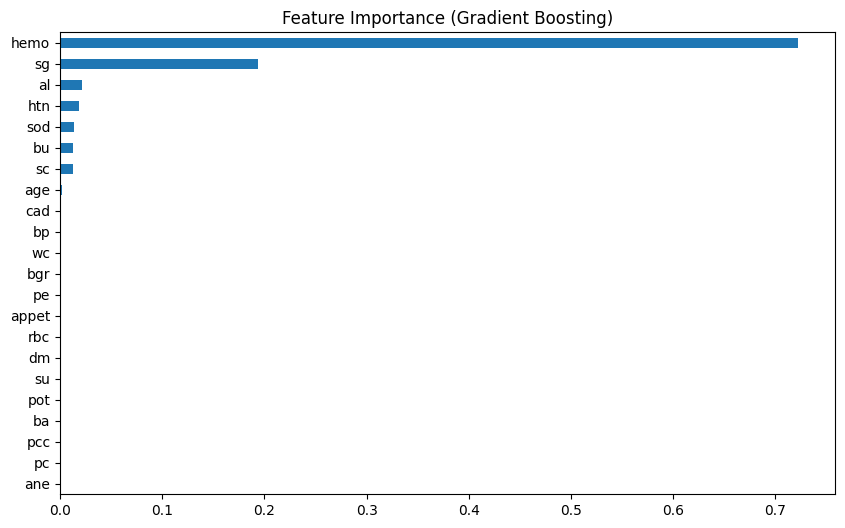

GB CV AUC: 0.9997916666666666


In [104]:
# сделаем Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Test Recall:", recall_score(y_test, y_pred_gb))
print("Test F1:", f1_score(y_test, y_pred_gb))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_gb))
print(confusion_matrix(y_test, y_pred_gb))

importances = pd.Series(gb.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)
print(importances.sort_values(ascending=False).head(15))
importances.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

gb = GradientBoostingClassifier(n_estimators=300)

cv_auc_gb = cross_val_score(gb, X_train, y_train, cv=5, scoring='roc_auc')
print("GB CV AUC:", cv_auc_gb.mean())